# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [91]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [93]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [94]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [95]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [96]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [97]:
print(plans.columns)

Index(['plan_name', 'messages_included', 'gb_per_month', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute'],
      dtype='object')


In [98]:
print(users.columns)

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')


In [99]:
print(usage.columns)

Index(['id', 'user_id', 'type', 'date', 'duration', 'length'], dtype='object')


In [100]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [154]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        4000 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 250.1+ KB


In [102]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [103]:
# cantidad de nulos para users
users.isna().sum()

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

In [104]:
# Proporción de valores nulos
users.isna().mean()

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

In [105]:
# cantidad de nulos para usage
usage.isna().sum()

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

In [106]:
# Proporción de nulos para usage
usage.isna().mean()

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



✍️ **Comentario**
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  
  La dataset 'users' en la columna 'City'hay 469 valores faltantes que corresponde al 11% de la data y en la columna 'churn' date hay 3534 valores faltantes que corresonde a 88% de la data. Ademas el dataset usage tiene data faltante especialmente en la columna 'duration' con una proporcion de 55% y 'length' tiene 17896 valores faltantates con una proporcion de 44%.
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

  
  No es aconsejable eliminar los filas con informacion faltante ya que puede afectar el resultado final y se puede incurrir en toma de decisiones incorrectas. Sin embargo, para efectos de lograr un resultado optimo, los valores faltantes se reemplazaran por una palabtra como NA, o Valor Ausente.




### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [155]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene una cantidad de registros de 4.000, siendo el valor mínimo 10.000 y el valor máximo 13.999. Además, tiene una desviación standar de 11.154 y una media de 11.999. Aparentemente no hay aparición de outliers ya que el interquatile Q1, Q2 y Q3 tienen una diferencia proporcional.
- La columna `age` tiene una mean de 33 años. Siendo la edad máxima 79, pero se ve una edad mínima de -999, lo cual probablemente sea un error que se daba corregir. Según el interquartile Q1, Q2 y Q3 no hay evidencia de outliers.

In [108]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` tienen una cantidad de registros de 40.000 con valores mínimos de 1 y 10.000 consecutivamente y valores máximos de 40.000 y 13.999. Además, el interquartile Q1, Q2 y Q3 tiene valores proporcionales para las dos columnas.

In [109]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

In [110]:
# explorar columnas categóricas de users
users.select_dtypes(include=['object']).columns.tolist()

['first_name', 'last_name', 'city', 'reg_date', 'plan', 'churn_date']

In [111]:
users['city'].unique()

array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [112]:
users['plan'].unique()

array(['Basico', 'Premium'], dtype=object)

- La columna `city` tiene caracteres como **?** y **nan** que deben ser corregidos para el analisis. 
- La columna `plan` tiene solo dos categorias y estan bien estructuradas. 

In [113]:
col_corregida = ['city']

In [114]:
for xd in col_corregida:
    users[xd] = users[xd].fillna('sin_dato')
    users[xd] = users[xd].replace('', 'sin_dato')
    users[xd] = users[xd].replace('?', 'sin_dato')

In [115]:
users['city'].unique()

array(['Medellín', 'sin_dato', 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)

In [116]:

# explorar columna categórica de usage
usage['type'].unique()


array(['call', 'text'], dtype=object)

- La columna `type` tiene unicamente dos categorias, 'call' y 'text'. No presenta valores faltantes.


---
✍️ **Comentario**:

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

   En la columna 'city' hay dos valores invalidos que son '?' y 'nan', no registran el nombre de la ciudad.
  
- ¿Qué acción tomarías?

  Estos han sido corregidos y reemplazados por la palabra 'sin_dato'.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [117]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'], format = '%Y-%m-%d')
users['reg_date'] = pd.to_datetime(users['reg_date'], format = '%Y-%m-%d', errors = 'coerce')

In [118]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        4000 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [119]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])
usage['date'] = pd.to_datetime(usage['date'], format = '%Y-%m-%d')
usage['date'] = pd.to_datetime(usage['date'], format = '%Y-%m-%d', errors = 'coerce')

In [120]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [121]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En la columna `reg_date` tiene informacion de los anos 2022, 2026, 2023, 2024. 

In [122]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En la columna `date` de 'usage' se ve unicamente en ano 2024. Basaremos el análisis en estas fechas.

✍️ **Comentario**:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

  Una vez revisadas las columnas 'reg_date' en `users` y 'date' en `usage`, se interpreta que el unico ano en comun es el 2024. Ademas, hay data de los anos 2022, 2023 e incluso ano 2026. 

- ¿Qué harías con ellas?

   Este análisis se realizará a el año 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [123]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, users['age'].median())

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [156]:
# Reemplazar ? por NA en city

for xd in col_corregida:
    users[xd] = users[xd].fillna('NA')
    users[xd] = users[xd].replace('?', 'NA')

In [157]:
# Verificar cambios
users['city'].unique()

array(['Medellín', 'sin_dato', 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)

In [126]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

In [127]:
# Verificar cambios
users['reg_date'].unique()

array(['2022-01-01T00:00:00.000000000', '2022-01-01T06:34:17.914478619',
       '2022-01-01T13:08:35.828957239', ...,
       '2024-12-30T10:51:24.171042768', '2024-12-30T17:25:42.085521392',
       '2024-12-31T00:00:00.000000000'], dtype='datetime64[ns]')

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [128]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_null'] = usage['duration'].isnull()

In [129]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_null'] = usage['length'].isnull()

In [130]:
usage.groupby('type')[['duration_null', 'length_null']].mean()

,duration_null,length_null
type,,
call,0.000000,0.99933
text,0.999276,0.00000


Según la tabla anterior, los resultados muestran que los valores nulos en `duration` y `length` no son aleatorios, missing at randmon, ya que tienen un comportamiento lógico y dependen de la variable type.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [131]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

usage.head()

,id,user_id,type,date,duration,length,duration_null,length_null,is_text,is_call
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,False,True,0,1
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,True,False,1,0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,True,False,1,0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN,False,True,0,1
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN,False,True,0,1


In [158]:
# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    {
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    }
).reset_index()

In [133]:
usage_agg.head()

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [134]:
print(usage_agg.columns)

Index(['user_id', 'is_text', 'is_call', 'duration'], dtype='object')


In [135]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})

In [136]:
print(usage_agg.columns)

Index(['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'], dtype='object')


In [137]:
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [138]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,sin_dato,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [139]:
# Resumen estadístico de las columnas numéricas
user_profile.describe(include = 'number')

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [140]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo: 
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

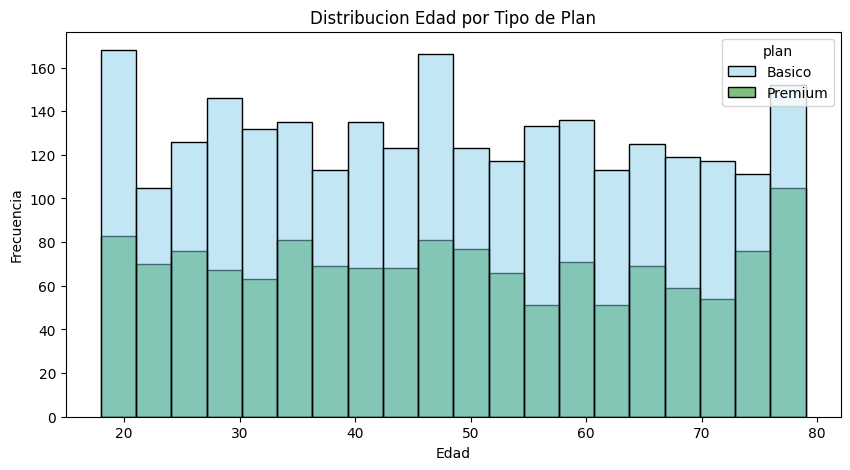

In [141]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10,5))
sns.histplot(data=user_profile,
            x='age',
            hue='plan',
            bins=20,
            palette=['skyblue','green'])

plt.title('Distribucion Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- El grafico de **Distribución Edad por Tipo de Plan**, muestra que los dos planes son acogidos por los usuarios en los diferentes tipos de rangos de edad. Sin embargo, el plan básico es más acogido y usado por los usuarios.
  En el plan Premium, la distribución es generalmente uniforme para la mayoría de los grupos de edades a excepción del último rango de edad que es aprox. 76-78 años en el que la frecuencia es más alta y resalta la preferencia.

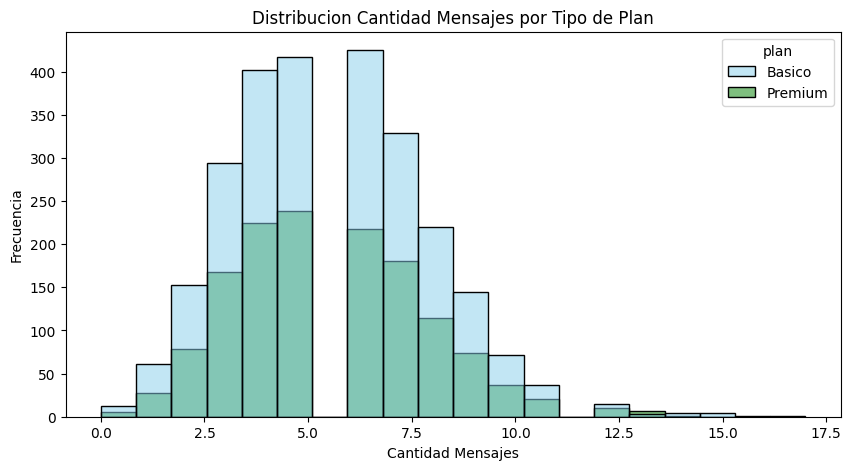

In [142]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(10,5))
sns.histplot(data=user_profile,
            x='cant_mensajes',
            hue='plan',
            bins=20,
            palette=['skyblue','green'])

plt.title('Distribucion Cantidad Mensajes por Tipo de Plan')
plt.xlabel('Cantidad Mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- El grafico de **Distribución Cantidad de Mensajes por Tipo de Plan** muestra que al igual que en el grafico anterior, el plan más popular y con mayor favoritismo es el 'Plan Básico', siendo más usado en la distribución de mensajes.
  Este Plan tiene una creciente de frecuencia de mensajes siendo la mas alta aproximadamente entre los 5 a 7.5 mensajes. Por otro lado, el 'Plan Premium', es menos escogido por los usuarios, sin embargo, tiene un comportamiento similar al 'Plan Básico'.

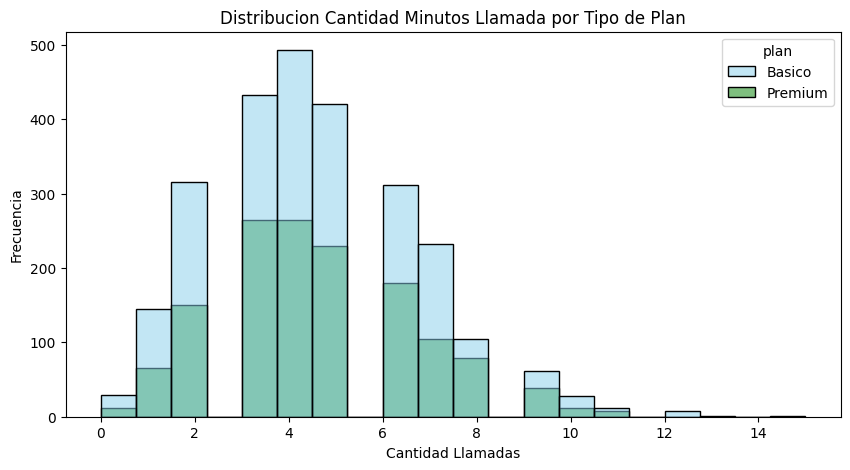

In [143]:
# Histograma para visualizar la cant_llamadas

plt.figure(figsize=(10,5))
sns.histplot(data=user_profile,
            x='cant_llamadas',
            hue='plan',
            bins=20,
            palette=['skyblue','green'])

plt.title('Distribucion Cantidad Minutos Llamada por Tipo de Plan')
plt.xlabel('Cantidad Llamadas')
plt.ylabel('Frecuencia')

plt.show()



💡Insights: 
- El histograma de **Distribución Cantidad de Minutos Llamada por Tipo de Plan** refleja que el plan con mayor frecuencia y uso es el 'Plan Básico' y tiene un comportamiento ascendente. Su pico más representativo está en la cantidad de 4 llamadas. El 'Plan Premium' esta aproximadamente al 50% del 'Plan Básico', teniendo un comportamiento creciente hasta las 4-5 llamadas y después decrece la cantidad. 


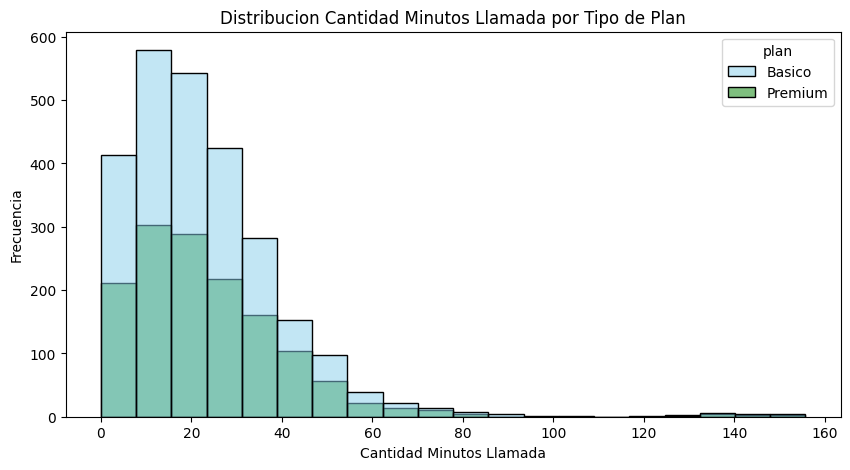

In [144]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(10,5))
sns.histplot(data=user_profile,
            x='cant_minutos_llamada',
            hue='plan',
            bins=20,
            palette=['skyblue','green'])

plt.title('Distribucion Cantidad Minutos Llamada por Tipo de Plan')
plt.xlabel('Cantidad Minutos Llamada')
plt.ylabel('Frecuencia')

plt.show()

- La **Distribución Cantidad Minutos Llamada por Tipo de Plan** tiene una frecuencia alta, principalmente para el 'Plan Básico', resaltando en la cantidad de 10 minutos aproximadamente por llamada. Para los dos planes, generalmente los usuarios hacen uso de llamadas por un rango de tiempo entre 0 y 50 minutos por llamada comúnmente. Sin embargo, hay muy pocos usuarios que tienen una duración de llamadas superiores a los 60 minutos hasta 160 minutos.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


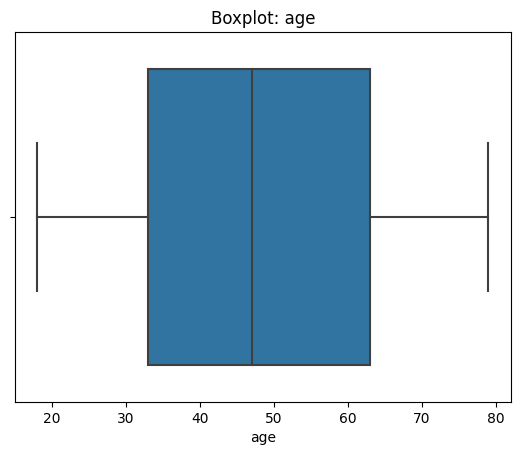

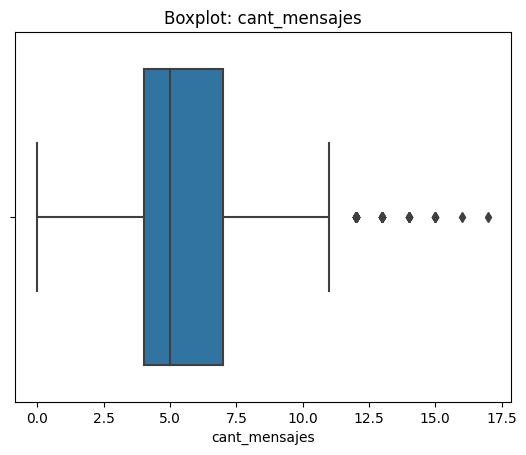

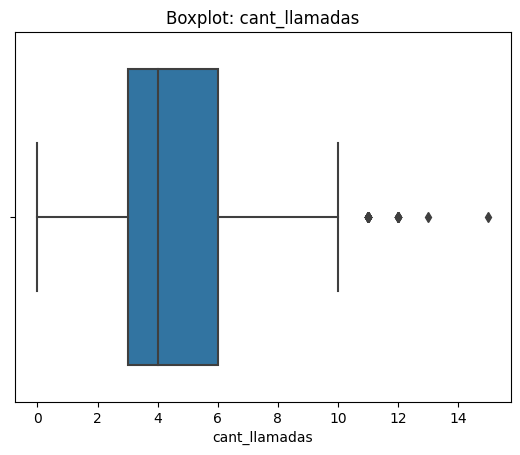

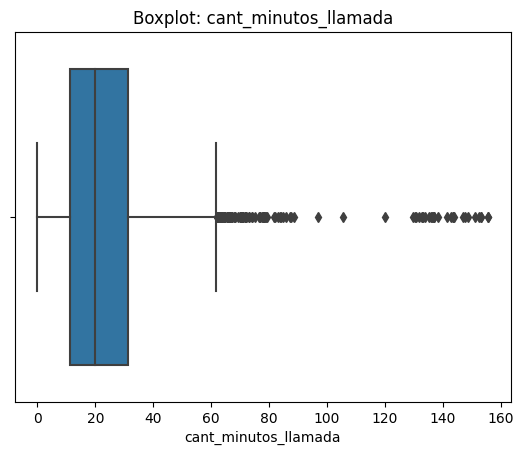

In [145]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()    

💡Insights: 
- Age: No presenta outliers. Tiene un comportamiento uniforme hacia los dos extremos. 
- cant_mensajes: Presenta outliers. Esto indica que hay un rango de usuarios que envían una cantidad alta de mensajes.
- cant_llamadas: Presenta outliers. Hay una cantidad pequeña de usuarios que tienen una frecuencia alta de llamadas  
- cant_minutos_llamada: Este Boxplot muestra una cantidad alta de outliers. Mostrando que hay una cantidad de usuarios que tienen un uso intensivo en la cantidad de minutos en las llamadas.

In [146]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

In [147]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- **cant_mensajes:** Es posible mantener los outliers, porque esto indica que hay un grupo de usuarios que tiene un uso alto del servicio de mensajería. Estos outliers no son errores de la data. 
- **cant_llamadas:** Lo outliers se deben mantener es este grupo, ya que no son errores, al contrario muestra un grupo reducido de usuarios que tienen un uso intensivo en el servicio de las llamadas.
- **cant_minutos_llamada:** Los outliers se debe de mantener ya que como se mostró anteriormente en el grafico de histograma, existe un grupo de usuarios con planes básico y premium que hacen un uso alto de la cantidad de minutos de llamadas superando los 80 minutos hasta 160 minutos aproximadamente. Este es un grupo importante y al eliminar los outliers se estaría modificando el comportamiento y distribución real del análisis.

---
## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [148]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) & (user_profile['grupo_uso'] != 'Bajo uso'),'grupo_uso'] = 'Uso medio'

In [149]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,sin_dato,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [150]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[(user_profile['age'] < 30) & (user_profile['age'] < 30), 'grupo_edad'] = 'Joven'

user_profile.loc[(user_profile['age'] < 60) & (user_profile['age'] < 60) & (user_profile['grupo_edad'] != 'Joven'), 'grupo_edad'] = 'Adulto'

In [151]:
# verificar cambios
user_profile.head(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,sin_dato,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5.0,7.0,44.97,Uso medio,Adulto Mayor
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3.0,5.0,28.39,Uso medio,Adulto
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3.0,5.0,30.23,Uso medio,Adulto Mayor
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5.0,5.0,28.85,Uso medio,Adulto Mayor
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5.0,3.0,5.99,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

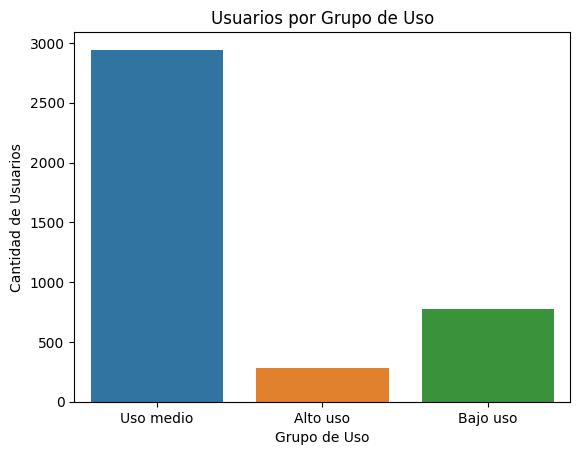

In [152]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

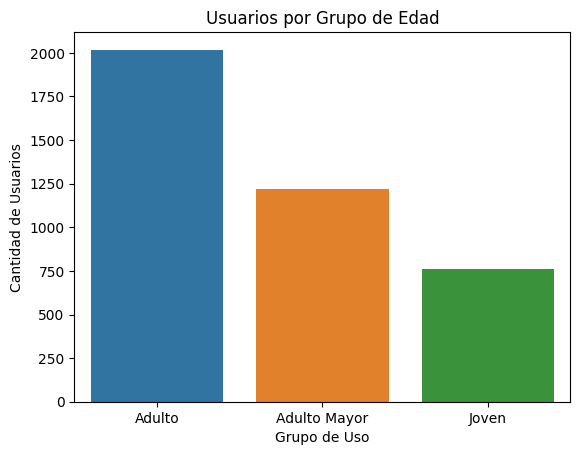

In [153]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

•	Los problemas iniciales en los datos fueron principalmente caracteres especial encontrados como “?”, relacionados como nombres de ciudades. 

•	Además, había una cantidad alta de datos faltantes, como, por ejemplo, para el dataset ‘users’ en la columna de ‘city’, había 469 valores nulos, lo que significa un 11.72% y 3534 para ‘churn’ lo que da una proporción de valores nulos de 88.35% 

•	Así mismo se presentó para el dataset ‘usage’.



🔍 **Segmentos por Edad**

•	Hay tres segmentos de clientes identificados como Joven, Adultos y Adulto Mayor. Estos han sido clasificados de acuerdo con la edad de la siguiente forma:
    
     - Joven: usuarios que tienen una edad mejor a 29 años.
     - Adultos: usuarios como edad entre 30 y 59 años.
     - Adulto Mayor: usuarios con edad mayor a 60 años. 
    
   Según la visualización realizada, el rango más importante de usuarios corresponde a los clientes catalogados como ‘Adultos’, es decir, usuarios menores a 29 años. Seguido por usuarios llamados ‘Adulto Mayor’ y finalmente el menor rango es para los usuarios de categoría ‘Joven’.



📊 **Segmentos por Nivel de Uso**

•	Los dos segmentos analizados (grupo de uso y edad) son valiosos e importantes para el análisis de ConnectaTel ya que por medio de los dos, se pueden tomar decisiones de mejorar ventas de acuerdo a la preferencia de usuarios ya sea por tipo de plan, edad o uso del plan. 

•	De acuerdo con la edad se puede tener una proyección de tipo de plan, grupo de edad, grupo de uso.  Esto impacta directamente a el área de mercadeo para establecer planes de acción y enfocarse en una segmentación según las necesidades. 



💡 **Recomendaciones**

•	Se presentaron patrones de uso extremo como outliers en el análisis, lo cual mostró grupo de clientes que tienen un comportamiento diferente a la mayoría, pero que son casos especiales y necesarios para tomar decisiones. Estos outliners no son errores de la data. Conociendo su comportamiento, se recomienda generar ofertas o planes especiales que sean atractivos a este tipo de personas para mantener su fidelidad a largo plazo con ConnectaTel.

•	El segmento más representativo es “Adulto”. Este segmento debe ser tratado con mayor preferencia, conociendo sus necesidades y prioridades para mantener el consumo con la ConnectaTel. Además, evaluar la opción de mantener los precios de los planes de acuerdo con sus beneficios y retenerlos por periodos de tiempo largo y/o incluir paquetes ilimitados en función de sus necesidades. 

•	Adicionalmente, aunque el plan mas representativo es el **Plan Básico**, se puede considerar la opción de ofrecer planes más económicos para el **Plan Premium** referentes a llamadas y mensajes, con el fin de aumentar ventas, mantener el cliente y tener una rotación de cartera baja. 


Link a repositorio público del proyecto: https://github.com/dcarolinaj 